In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import crosscoders as xc
import torch
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd

import datetime


------------------------- CONSTANTS -------------------------
GlobalsConfig(
    PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
    CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.tiny-stories-33M.yml',
    DATA_DIR = '/home/ec2-user/crosscoders/data',
    EXPERIMENT = ExperimentConfig(
        BATCH_SIZE = 16384,
        MAX_RECORDS = None,
        MAX_BATCHES = 1000000,
        MAX_TOKENS = 1000000,
        NUM_GPUS = 1,
        NUM_TRAINERS = 1,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
)
-------------------------------------------------------------



In [3]:
import ray, ray.tune
from ray import tune
from ray.tune.schedulers import ASHAScheduler

from hyperopt import hp
from ray.tune.search.hyperopt import HyperOptSearch

from ray.tune.progress_reporter import CLIReporter, JupyterNotebookReporter

In [4]:
from src.scripts.train import train_loop_per_worker

In [5]:
from crosscoders.constants import CONSTANTS
from crosscoders.dataclasses.configs.runner import RunnerConfig
from crosscoders.utils import from_dict, get_config


runner_cfg = from_dict(
    RunnerConfig,
    get_config(CONSTANTS.CONFIG_FILEPATH).get('RUNNER', {})
)
runner_cfg

RunnerConfig(
    MODEL = ModelConfig(
        CAUSALITY = 'acausal',
        LOCALITY = 'global',
        ACTIVATION_FUNCTION = 'relu',
        eps = 2,
        N_LAYERS = 4,
        D_MODEL = 768,
        D_CODER = 16384,
        HARDWARE = HardwareConfig(
            dtype = torch.float32,
            device = 'cuda',
        ),
    ),
    LOSS = LossConfig(
        c = 4,
        lambda_s = 10,
        lambda_p = 3e-06,
    ),
    OPTIMIZER = OptimizerConfig(
        optimizer = <class 'torch.optim.adam.Adam'>,
        parameters = OptimizerParameters(
            lr = 0.0004,
            betas = (0.9, 0.999),
            fused = True,
        ),
    ),
    INPUT_NAME = 'tiny-stories-33M.ln2.normalized',
    OUTPUT_NAME = 'tiny-stories-33M.mlp_out',
)

In [ ]:
import ray

ray.init()

2025-02-22 08:31:11,415	INFO worker.py:1654 -- Connecting to existing Ray cluster at address: 10.0.1.126:6379...
[2025-02-22 08:31:16,424 W 2368 2368] gcs_rpc_client.h:148: Failed to connect to GCS at address 10.0.1.126:6379 within 5 seconds.
[2025-02-22 08:31:46,425 W 2368 2368] gcs_client.cc:178: Failed to get cluster ID from GCS server: TimedOut: Timed out while waiting for GCS to become available.
[2025-02-22 08:31:52,430 W 2368 2368] gcs_rpc_client.h:148: Failed to connect to GCS at address 10.0.1.126:6379 within 5 seconds.
2025-02-22 08:32:10,436	INFO worker.py:1832 -- Connected to Ray cluster. View the dashboard at http://127.0.0.1:8265 


Python version:,3.12.8
Ray version:,2.42.1
Dashboard:,http://127.0.0.1:8265


(pid=7710) 
(pid=7710) ------------------------- CONSTANTS -------------------------
(pid=7710) GlobalsConfig(
(pid=7710)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(pid=7710)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
(pid=7710)     DATA_DIR = '/home/ec2-user/crosscoders/data',
(pid=7710)     EXPERIMENT = ExperimentConfig(
(pid=7710)         BATCH_SIZE = 16384,
(pid=7710)         MAX_RECORDS = None,
(pid=7710)         MAX_BATCHES = 1000000,
(pid=7710)         MAX_TOKENS = 10000000,
(pid=7710)         NUM_GPUS = 1,
(pid=7710)         NUM_TRAINERS = 1,
(pid=7710)         HARDWARE = HardwareConfig(
(pid=7710)             dtype = torch.float32,
(pid=7710)             device = 'cuda',
(pid=7710)         ),
(pid=7710)     ),
(pid=7710) )
(pid=7710) -------------------------------------------------------------
(pid=7710) 
(train_loop_per_worker pid=7710) RunnerConfig(
(train_loop_per_worker pid=7710)     MODEL = ModelConfig(
(train_loop_per_wo

(train_loop_per_worker pid=7710) Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-22_08-32-07_881199_2636/logs/ray-data
(train_loop_per_worker pid=7710) Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=10000000]
(raylet) [2025-02-22 08:36:09,980 E 2829 2829] node_manager.cc:3178: 3 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431, IP: 10.0.1.126) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 10.0.1.126`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the en

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: f42e53fe8a401e554d7279d06f51c8684ace850a01000000 Worker ID: 7a54e8d742e2aac38e6118b8c9456fbc6c42a60f8a9a6dd585491c42 Node ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431 Worker IP address: 10.0.1.126 Worker port: 10044 Worker PID: 21351 Worker exit type: SYSTEM_ERROR Worker exit detail: The leased worker has unrecoverable failure. Worker is requested to be destroyed when it is returned. Worker exits with an exit code 1. SystemExit is raised (sys.exit is called). Exit code: 1. The process receives a SIGTERM.


...

(train_loop_per_worker pid=32883) Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-22_08-32-07_881199_2636/logs/ray-data
(train_loop_per_worker pid=32883) Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=10000000]
(raylet) [2025-02-22 08:44:09,992 E 2829 2829] node_manager.cc:3178: 2 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431, IP: 10.0.1.126) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 10.0.1.126`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the 

(raylet) A worker died or was killed while executing a task by an unexpected system error. To troubleshoot the problem, check the logs for the dead worker. RayTask ID: 0fcc9a2796fa47edc48af8b251c876c35ed149bb01000000 Worker ID: 8defeaaf7201dca72543af098baa986350db36503919328f22e64cb4 Node ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431 Worker IP address: 10.0.1.126 Worker port: 10156 Worker PID: 79099 Worker exit type: SYSTEM_ERROR Worker exit detail: Worker unexpectedly exits with a connection error code 2. End of file. There are some potential root causes. (1) The process is killed by SIGKILL by OOM killer due to high memory usage. (2) ray stop --force is called. (3) The worker is crashed unexpectedly due to SIGSEGV or other unexpected errors.


(raylet) [2025-02-22 08:59:10,020 E 2829 2829] node_manager.cc:3178: 1 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431, IP: 10.0.1.126) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 10.0.1.126`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.


(pid=79571) 
(pid=79571) ------------------------- CONSTANTS -------------------------
(pid=79571) GlobalsConfig(
(pid=79571)     PROJECT_ROOT_DIR = '/home/ec2-user/crosscoders',
(pid=79571)     CONFIG_FILEPATH = '/home/ec2-user/crosscoders/src/scripts/configs/train.yml',
(pid=79571)     DATA_DIR = '/home/ec2-user/crosscoders/data',
(pid=79571)     EXPERIMENT = ExperimentConfig(
(pid=79571)         BATCH_SIZE = 16384,
(pid=79571)         MAX_RECORDS = None,
(pid=79571)         MAX_BATCHES = 1000000,
(pid=79571)         MAX_TOKENS = 10000000,
(pid=79571)         NUM_GPUS = 1,
(pid=79571)         NUM_TRAINERS = 1,
(pid=79571)         HARDWARE = HardwareConfig(
(pid=79571)             dtype = torch.float32,
(pid=79571)             device = 'cuda',
(pid=79571)         ),
(pid=79571)     ),
(pid=79571) )
(pid=79571) -------------------------------------------------------------
(pid=79571) 
(train_loop_per_worker pid=79571) RunnerConfig(
(train_loop_per_worker pid=79571)     MODEL = ModelCon

(train_loop_per_worker pid=79571) Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-22_08-32-07_881199_2636/logs/ray-data
(train_loop_per_worker pid=79571) Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquet] -> LimitOperator[limit=10000000]
(raylet) [2025-02-22 09:00:10,023 E 2829 2829] node_manager.cc:3178: 1 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 0159838f44ea81982d6bd9818343df8f20317dd2d64a718dd83eb431, IP: 10.0.1.126) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 10.0.1.126`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the 

In [10]:
CONSTANTS.EXPERIMENT.MAX_TOKENS = 10000000

In [11]:
from crosscoders.data.dataset import TinyStoriesRayDataset


activations_ds = TinyStoriesRayDataset(s3_prefix='tiny-stories-33M/10M/').load('activations')
activations_ds

2025-02-22 22:11:32,672	WARNING file_meta_provider.py:211 -- Skipping expansion of 2555 path(s). If your paths contain directories or if file size collection is required, try rerunning this read with `meta_provider=DefaultFileMetadataProvider()`.
2025-02-22 22:11:32,701	INFO streaming_executor.py:108 -- Starting execution of Dataset. Full logs are in /tmp/ray/session_2025-02-22_21-29-10_106360_13733/logs/ray-data
2025-02-22 22:11:32,702	INFO streaming_executor.py:109 -- Execution plan of Dataset: InputDataBuffer[Input] -> TaskPoolMapOperator[ReadParquetBulk]


Running 0: 0.00 row [00:00, ? row/s]

- ReadParquetBulk 1: 0.00 row [00:00, ? row/s]

limit=10000000
+- Dataset(
      num_rows=?,
      schema={
         tokens: int32,
         tiny-stories-33M.ln2.nor...: numpy.ndarray(shape=(4, 768), dtype=float),
         tiny-stories-33M.mlp_out: numpy.ndarray(shape=(4, 768), dtype=float),
         tiny-stories-33M.resid_post: numpy.ndarray(shape=(4, 768), dtype=float)
      }
   )

In [ ]:
# from crosscoders.data.scale import *



# stats = get_stats('crosscoders', 'input/roneneldan/TinyStories/tiny-stories-33M/mlp_out/stats.json')
# stats

{'tiny-stories-33M.mlp_in': 1.555504102821306,
 'tiny-stories-33M.mlp_out': 2.6822854254201425}

In [12]:
hps = {
    'OPTIMIZER': {
        'parameters': {
            # 'lr': ray.tune.sample_from(lambda spec: 10 ** (-10 * np.random.rand()))
            # 'lr': np.logspace(-4, -3, 10)
            # 'lr': ray.tune.sample_from(lambda _: (np.random.rand() + 1e-4) * (1e-3 - 1e-4))
            # 'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3)),
            # 'lr': hp.qloguniform('lr', np.log(1e-5), np.log(1e-3), 1e-5),
            'lr': hp.qloguniform('lr', np.log(1e-4), np.log(1e-3), 1e-4),
            # 'lr': hp.choice('lr', lrs)
        }
    },
    # 'LOSS': {
    #     # 'L1_COEFFICIENT': hp.choice('L1_COEFFICIENT', L1_COEFFICIENTs),
    #     # 'L1_COEFFICIENT': hp.loguniform('L1_COEFFICIENT', np.log(1e-1), np.log(1e1)),
    #     # 'L1_COEFFICIENT': hp.qloguniform('L1_COEFFICIENT', np.log(1e-1), np.log(1e1), 1e-1),
    #     'L1_COEFFICIENT': ray.tune.grid_search([1., 2., 10.])
    # }
    # 'scale': ray.tune.grid_search([True, False])
}

hps = {
    'OPTIMIZER': {
        'parameters': {
            # 'lr': ray.tune.sample_from(lambda spec: 10 ** (-10 * np.random.rand()))
            # 'lr': np.logspace(-4, -3, 10)
            # 'lr': ray.tune.sample_from(lambda _: (np.random.rand() + 1e-4) * (1e-3 - 1e-4))
            # 'lr': hp.loguniform('lr', np.log(1e-5), np.log(1e-3)),
            # 'lr': hp.qloguniform('lr', np.log(1e-5), np.log(1e-3), 1e-5),
            'lr': hp.choice('lr', [2e-4]),
            # 'lr': hp.choice('lr', lrs)
        }
    },
    'LOSS': {
        # 'L1_COEFFICIENT': hp.choice('L1_COEFFICIENT', L1_COEFFICIENTs),
        # 'L1_COEFFICIENT': hp.loguniform('L1_COEFFICIENT', np.log(1e-1), np.log(1e1)),
        # 'L1_COEFFICIENT': hp.qloguniform('L1_COEFFICIENT', np.log(1e-1), np.log(1e1), 1e-1),
        # 'L1_COEFFICIENT': ray.tune.grid_search([1., 2., 10.])
        # 'lambda_s'
    }
    # 'scale': ray.tune.grid_search([True, False])
}

hps = {
    'OPTIMIZER': {
        'parameters': {
            'lr': ray.tune.grid_search([2e-4])
        }
    },
    'LOSS': {
        'c': ray.tune.grid_search([2, 4, 8]),
        'lambda_s': ray.tune.grid_search([5, 10, 20]),
        'lambda_p': ray.tune.grid_search([3e-7, 3e-6, 3e-5]),
    }
    # 'scale': ray.tune.grid_search([True, False])
}

hps = {
    'OPTIMIZER': {
        'parameters': {
            'lr': ray.tune.grid_search([2e-4])
        }
    },
    'LOSS': {
        'c': ray.tune.grid_search([4]),
        'lambda_s': ray.tune.grid_search([.1]),
        'lambda_p': ray.tune.grid_search([3e-6]),
    }
    # 'scale': ray.tune.grid_search([True, False])
}

hps = {
    'OPTIMIZER': {
        'parameters': {
            'lr': ray.tune.grid_search([2e-4])
        }
    },
    'LOSS': {
        'lambda_s': ray.tune.grid_search([2]),
    }
    # 'scale': ray.tune.grid_search([True, False])
}

ray_cfg = {
    'RUNNER': hps,
}

2025-02-22 22:11:35,133	ERROR worker.py:422 -- Unhandled error (suppress with 'RAY_IGNORE_UNHANDLED_ERRORS=1'): ray::ReadParquetBulk() (pid=121608, ip=10.0.1.126)
    for b_out in map_transformer.apply_transform(iter(blocks), ctx):
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/data/_internal/execution/operators/map_transformer.py", line 392, in __call__
    for data in iter:
                ^^^^
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/data/_internal/execution/operators/map_transformer.py", line 253, in __call__
    yield from self._block_fn(input, ctx)
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/data/_internal/planner/plan_read_op.py", line 106, in do_read
    yield from read_task()
  File "/home/ec2-user/crosscoders/.conda/lib/python3.12/site-packages/ray/data/datasource/datasource.py", line 168, in __call__
    yield from r

In [ ]:
# # (27.712812921102035, 141.501510296875, 0.1958481776128015)
# scaled_model_dim, x_mean_l2, X_SCALAR = (27.712812921102035, 141.501510296875, 0.1958481776128015)
# X_SCALAR = 0.19710070135032787
# scaled_model_dim, x_mean_l2, X_SCALAR

(27.712812921102035, 141.501510296875, 0.19710070135032787)

In [13]:
tuner = ray.tune.Tuner(
    ray.tune.with_resources(
        # ray.tune.with_parameters(train_loop_per_worker, train_ds=activations_ds, X_SCALAR=stats['tiny-stories-33M.mlp_in']),
        ray.tune.with_parameters(train_loop_per_worker, train_ds=activations_ds),
        {'gpu': 1}
    ),
    param_space=hps,
    tune_config=ray.tune.TuneConfig(
        num_samples=1,
        scheduler = ASHAScheduler(
            time_attr='n_tokens',
            # time_attr='training_iteration',
            metric='loss',
            mode='min',
            # metric='explained_variance',
            # mode='max',
            # max_t=8192 * 123,
            # grace_period=8192 * 50,
            # max_t=1000,
            max_t=10000000,
            # grace_period=1000000,
            # max_t=10000000,
            grace_period=200000,
            # grace_period=300000,
            # max_t=2000000,
            # grace_period=1000000,
            # max_t=10, # 50, # 250,
            # grace_period=3,
            # reduction_factor=3,
            # brackets=1,
        ),
        # search_alg=HyperOptSearch(hps, metric='loss', mode='min')
    ),
    run_config=ray.tune.RunConfig(
        name=f'Tuner_{datetime.datetime.now(datetime.UTC).strftime("%Y-%m-%d_%H:%M:%S")}',
        storage_path='s3://crosscoders/ray/tune/jumprelu/uniform_init/causal',
        progress_reporter=JupyterNotebookReporter(
            metric_columns=[
                'n_tokens',
                'loss',
                'error',
                # 'l1',
                'l0',
                'explained_variance',
                'dead_neurons/one_token'
                # 'dead_neurons/no_token'
            ],
            # parameter_columns={
            #     'OPTIMIZER/parameters/lr': 'lr',
            #     'LOSS/L1_'
            # },
            # max_column_length=10,
            metric='loss',
            mode='min',
            sort_by_metric=True
        )
    ),

)
results = tuner.fit()

2025-02-22 22:11:45,484	INFO tune.py:616 -- [output] This uses the legacy output and progress reporter, as Jupyter notebooks are not supported by the new engine, yet. For more information, please see https://github.com/ray-project/ray/issues/36949


(pid=121973) Running 0: 0.00 row [00:00, ? row/s]

2025-02-22 22:35:57,817	INFO tune.py:1009 -- Wrote the latest version of all result files and experiment state to 'crosscoders/ray/tune/jumprelu/uniform_init/causal/Tuner_2025-02-22_22:11:44' in 0.5485s.
2025-02-22 22:35:57,822	INFO tune.py:1041 -- Total run time: 1452.34 seconds (1451.52 seconds for the tuning loop).


In [28]:
results

ResultGrid<[
  Result(
    metrics={'loss': 726703.0, 'error': 726477.375, 'l1': 225.60147094726562, 'l0': 8126.05078125, 'explained_variance': 0.0025609731674194336, 'dead_neurons/all_tokens': 0.00164794921875, 'dead_neurons/one_token': 0.9979248046875, 'dead_neurons/no_token': 0.0020751953125, 'n_tokens': 8192},
    path='crosscoders/ray/tune/Tuner_2025-02-14_23:01:10/train_loop_per_worker_7d526019_1_lr=0.0060_2025-02-14_23-01-11',
    filesystem='s3',
    checkpoint=None
  )
]>

In [25]:
results.get_best_result(metric='l0', mode='min')

Result(
  metrics={'loss': 713299.6875, 'error': 713075.125, 'l1': 224.58995056152344, 'l0': 8059.93603515625, 'explained_variance': 0.002606511116027832, 'dead_neurons/all_tokens': 0.00146484375, 'dead_neurons/one_token': 0.99847412109375, 'dead_neurons/no_token': 0.00152587890625, 'n_tokens': 8192},
  path='crosscoders/ray/Tuner_2025-02-14_22:35:53/train_loop_per_worker_9daee2d6_1_lr=0.0050_2025-02-14_22-35-54',
  filesystem='s3',
  checkpoint=None
)

In [22]:
experiment_path = '/home/ec2-user/ray_results/train_loop_per_worker_2025-02-11_21-49-40'

tuner = tune.Tuner.restore(experiment_path, trainable=train_loop_per_worker)
result_grid = tuner.get_results()

In [27]:
df = result_grid.get_dataframe()
df = df[[
    'config/OPTIMIZER/parameters/lr',
    'n_tokens',
    'loss',
    'error',
    'l1',
    'l0',
    'explained_variance',
    'dead_neurons/all_tokens',
    'dead_neurons/one_token',
    'dead_neurons/no_token'
]]

df.sort_values(['explained_variance', 'l0', 'error'], ascending=[False, True, True])


,config/OPTIMIZER/parameters/lr,n_tokens,loss,error,l1,l0,explained_variance,dead_neurons/all_tokens,dead_neurons/one_token,dead_neurons/no_token
12,0.000356,1000000,23162.277344,18334.083984,4828.193359,2287.291748,0.967842,0.003052,0.656311,0.343689
3,0.000188,1000000,24290.962891,19276.001953,5014.961426,4858.826660,0.965666,0.000122,0.903809,0.096191
5,0.000197,1000000,24549.335938,19761.744141,4787.591309,4546.876953,0.951847,0.002808,0.887573,0.112427
11,0.000198,1000000,24518.539062,19812.705078,4705.834473,4475.717285,0.951716,0.003052,0.890015,0.109985
6,0.000848,1000000,26706.621094,22459.750000,4246.871094,523.086792,0.945373,0.002930,0.154663,0.845337
17,0.002279,1000000,37020.894531,33015.269531,4005.624268,84.085068,0.942557,0.000000,0.028870,0.971130
2,0.002797,1000000,41995.042969,38436.222656,3558.819580,59.899307,0.933527,0.000000,0.022583,0.977417
18,0.001929,1000000,33290.945312,29255.753906,4035.190186,114.310768,0.931947,0.000610,0.037109,0.962891
8,0.001866,1000000,33445.757812,29571.507812,3874.248291,124.401039,0.929910,0.001038,0.038147,0.961853
15,0.001965,1000000,37700.617188,33825.785156,3874.832520,111.956596,0.923191,0.000854,0.033936,0.966064


In [ ]:
# train_loop_per_worker_b08f9618	TERMINATED	10.0.1.126:605564	0.295722	0.000180638	1000000	21609.8	19582.3	6856.1	5908.99
lr = 0.000180638
L1_COEFFICIENT = 0.295722

In [ ]:
'/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/'

In [31]:
results

ResultGrid<[
  Result(
    metrics={'loss': 41580.7890625, 'l1': 3500.9423828125, 'l0': 410.6602783203125, 'n_tokens': 507904},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_37a57574_1_lr=0.0010_2025-02-10_23-44-38',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 26639.958984375, 'l1': 4489.40185546875, 'l0': 460.3125, 'n_tokens': 1000000},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_8e091535_2_lr=0.0010_2025-02-10_23-44-45',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 37124.46484375, 'l1': 5299.7578125, 'l0': 7630.24267578125, 'n_tokens': 507904},
    path='/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_23-44-38/train_loop_per_worker_3ded7943_3_lr=0.0001_2025-02-10_23-44-53',
    filesystem='local',
    checkpoint=None
  ),
  Result(
    metrics={'loss': 35988.59765625, 'l1': 4773.79736328125, 

In [24]:
dfs = {result.path: result.metrics_dataframe for result in results}

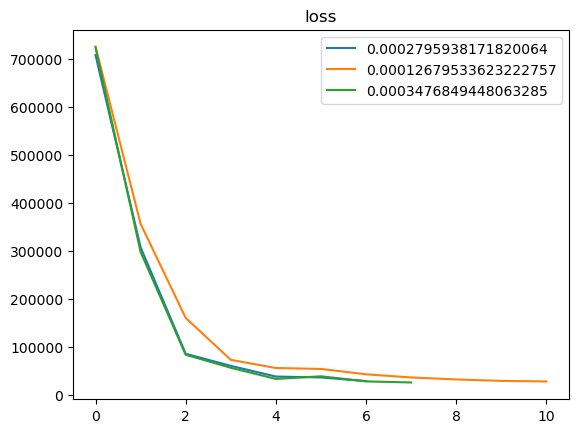

In [27]:

[d.loss.plot(label=d['config/OPTIMIZER/parameters/lr'][0]) for d in dfs.values() if 'loss' in d.columns]
plt.title('loss')
plt.legend()
# dfs['/home/ec2-user/ray_results/train_loop_per_worker_2025-02-10_22-29-19/train_loop_per_worker_78230_00000_0_2025-02-10_22-29-19']
# dfs

In [65]:
# for result in results:
#     display(result.metrics_dataframe.iloc[-1][['config/OPTIMIZER/parameters/lr', 'loss', 'l1', 'l0']])

results_df = pd.DataFrame([result.metrics_dataframe.iloc[-1][['config/OPTIMIZER/parameters/lr', 'n_tokens', 'loss', 'l1', 'l0']] for result in results])
results_df.rename(columns={'config/OPTIMIZER/parameters/lr': 'lr'}, inplace=True)
results_df.sort_values(['loss', 'l0'], inplace=True)
results_df

,lr,n_tokens,loss,l1,l0
122,0.000401,1000000,21639.250000,4740.429688,1930.038208
122,0.000491,1000000,24664.117188,4726.380371,1347.833374
122,0.000207,1000000,25330.941406,4693.235352,4313.798828
122,0.000450,1000000,25462.597656,4461.587402,1556.486084
122,0.000969,1000000,26639.958984,4489.401855,460.312500
122,0.000910,1000000,26678.003906,4342.301758,455.369781
61,0.000963,507904,31442.949219,3585.637695,474.313110
61,0.000156,507904,35988.597656,4773.797363,6555.136719
61,0.000124,507904,37124.464844,5299.757812,7630.242676
61,0.000985,507904,41580.789062,3500.942383,410.660278
